# 3_angry_mob
ensemble testing a set of pitchfork networks
ToDo:
- Plots of different solar tracks at low alpha plotted over true track
- Plots of distributions of output predictions for different points
- Plots of standard deviation of uncertainty distributions as a function of N

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
from scipy import stats
import random
import astropy.constants
from numpy.random import default_rng

#### graphical
import matplotlib.pyplot as plt

plt.style.use("Solarize_Light2")
plt.rcParams.update({"axes.edgecolor": "black"})

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="0"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-07-11 13:39:16.384397: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-11 13:39:16.384427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-11 13:39:16.385399: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-11 13:39:16.390261: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-11 13:39:16.933698: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-07-11 13:39:17.436622: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18158 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


## 1) load in grid
keep same routine as during training

In [2]:
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/barbie_nu.h5', key='df')

#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.995, random_state=seed)
df_test = df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.005, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Testing set: ", len(df_test))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  1149302
Testing set:  5804
Validation set:  5776


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std,log_nu_0_41_std,log_nu_0_42_std,log_nu_0_43_std,log_nu_0_44_std,log_nu_0_45_std
count,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,...,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06
mean,1.018413e+00,1.576475e-02,2.782837e-01,1.800447e+00,4.628984e+00,1.132672e+00,1.811612e+00,6.040085e+03,1.364829e-02,2.695808e+03,...,6.778618e-15,-2.855876e-15,1.653083e-15,4.966201e-15,7.047146e-16,7.653635e-15,-2.083393e-15,4.996951e-15,2.264860e-15,-4.464009e-15
std,1.188714e-01,1.314553e-02,2.294834e-02,1.153523e-01,3.492387e+00,2.576956e-01,1.362638e+00,6.644132e+02,1.252237e-02,9.594349e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,7.000000e-01,1.241437e-03,2.400195e-01,1.600098e+00,1.865560e-02,6.006561e-01,2.575467e-01,4.663410e+03,9.960149e-05,7.069718e+02,...,-3.256371e+00,-3.256499e+00,-3.256724e+00,-3.256984e+00,-3.257242e+00,-3.257479e+00,-3.257698e+00,-3.257904e+00,-3.258101e+00,-3.258289e+00
25%,9.330000e-01,4.428834e-03,2.583105e-01,1.700684e+00,1.798067e+00,9.507823e-01,8.449202e-01,5.545393e+03,2.653046e-03,1.978679e+03,...,-6.128663e-01,-6.127785e-01,-6.126330e-01,-6.124484e-01,-6.122666e-01,-6.121199e-01,-6.119341e-01,-6.117809e-01,-6.116612e-01,-6.114950e-01
50%,1.035000e+00,1.159459e-02,2.773438e-01,1.800146e+00,3.836663e+00,1.088573e+00,1.414103e+00,5.952699e+03,9.949250e-03,2.654218e+03,...,1.245599e-01,1.246725e-01,1.248018e-01,1.249217e-01,1.250079e-01,1.250797e-01,1.251489e-01,1.252120e-01,1.252990e-01,1.254035e-01
75%,1.116000e+00,2.475267e-02,2.978125e-01,1.900488e+00,6.870449e+00,1.264503e+00,2.353924e+00,6.415778e+03,2.235996e-02,3.367139e+03,...,7.340587e-01,7.339929e-01,7.338441e-01,7.337370e-01,7.336355e-01,7.335394e-01,7.334309e-01,7.333475e-01,7.332500e-01,7.331606e-01
max,1.200000e+00,5.053113e-02,3.199902e-01,1.999951e+00,1.399994e+01,2.117572e+00,1.547402e+01,8.882541e+03,5.051477e-02,6.181659e+03,...,2.499163e+00,2.499528e+00,2.499303e+00,2.499460e+00,2.499623e+00,2.499766e+00,2.499893e+00,2.500011e+00,2.500124e+00,2.500231e+00


In [3]:
"""
pca
"""
#### define pca global vars
n_components = 5
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 5 is 0.9999999738098698


In [4]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array([0.01, 0.02, 0.001,0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] / df_full[["radius", "luminosity", "surface_Z"] + [f'nu_0_{i+1}' for i in range(14,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity", "log_surface_Z"] + [f'log_nu_0_{i+1}' for i in range(14,25)]].std()


weights = log_weights.values.tolist()

print(weights)

[0.0404396032697295, 0.01593228797007494, 0.04452107630433814, 0.00016667030242831007, 0.00015733933591581152, 0.0001491147982946965, 0.00014175098532282846, 0.00013505912143240066, 0.000128934434739406, 0.0001233175056851056, 0.00011815420774364464, 0.00011339103527327905, 0.00010897713404833435, 0.00010486947466103136]


In [5]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

def rescale_preds(preds, df, column):
    if 'star_feh' in column:
        return (preds[column+"_std"]*df[column].std())+df[column].mean()
    else:
        return 10**((preds["log_"+column+"_std"]*df["log_"+column].std())+df["log_"+column].mean())

## Calculating error function for angry mob


In [7]:
"""
load in angry mob
"""
pca_comps = pca.components_
pca_mean = pca.mean_

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}

angry_mob = {}

pitchfork_ids = [i for i in range(434)] + [i for i in range(500, 788)]

for i in pitchfork_ids:
    pitchfork_name = "barbie_pitchfork_"+str(i)
    print("loaded in pitchfork " + str(i), end="\r")
    angry_mob[pitchfork_name] = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/barbie/angry_mob/" + pitchfork_name + ".h5", custom_objects=custom_objects)


In [15]:
i = 0
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

pred_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std'] + [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(14,25)]

pitchfork_name = "barbie_pitchfork_"+str(i)

pcann_model = angry_mob[pitchfork_name]

preds = pcann_model(np.array(df_test[inputs]))

preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)


for output in outputs:
    preds_df[output] = rescale_preds(preds_df, df_full, output)

preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

In [8]:
"""
solar like test point, expand to more later
"""

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit_sol = df_mass_zinit[df_mass_zinit["star_age"] == df_mass_zinit.iloc[(df_mass_zinit['star_age']-4.6).abs().argsort()[:1]]['star_age'].tolist()[0]]
df_mass_zinit_sol = df_mass_zinit_sol.set_index(np.arange(0,len(df_mass_zinit_sol)))
df_mass_zinit_sol

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std,log_nu_0_41_std,log_nu_0_42_std,log_nu_0_43_std,log_nu_0_44_std,log_nu_0_45_std
0,1.0,0.011711,0.258145,1.95166,4.598003,0.998859,1.139369,5974.615127,0.010469,3049.950257,...,0.539422,0.539123,0.538904,0.538725,0.538559,0.538397,0.538238,0.538085,0.537939,0.537799


In [5]:
"""
FOR SKILLS SESSION
"""

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit_sol = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))
df_mass_zinit_sol

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std,log_nu_0_41_std,log_nu_0_42_std,log_nu_0_43_std,log_nu_0_44_std,log_nu_0_45_std
0,1.0,0.011711,0.258145,1.95166,0.036160,0.867375,0.792732,5855.636631,0.011708,4086.797425,...,1.245112,1.244821,1.244596,1.244425,1.244270,1.244115,1.243962,1.243813,1.243670,1.243534
1,1.0,0.011711,0.258145,1.95166,0.036219,0.867134,0.791970,5855.040879,0.011708,4089.270694,...,1.246494,1.246212,1.245987,1.245816,1.245661,1.245506,1.245353,1.245204,1.245061,1.244925
2,1.0,0.011711,0.258145,1.95166,0.036437,0.866310,0.789314,5852.909421,0.011708,4097.804269,...,1.251241,1.250991,1.250766,1.250594,1.250439,1.250283,1.250129,1.249980,1.249837,1.249700
3,1.0,0.011711,0.258145,1.95166,0.037248,0.864059,0.781592,5846.142218,0.011708,4121.568140,...,1.264241,1.264073,1.263846,1.263673,1.263517,1.263360,1.263205,1.263055,1.262912,1.262774
4,1.0,0.011711,0.258145,1.95166,0.040260,0.862161,0.771568,5833.717037,0.011707,4144.138735,...,1.275334,1.275247,1.275019,1.274845,1.274687,1.274530,1.274373,1.274222,1.274077,1.273938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,1.0,0.011711,0.258145,1.95166,10.478003,1.777468,2.588691,5498.763284,0.010772,1003.295329,...,-2.299412,-2.300426,-2.301451,-2.302452,-2.303411,-2.304320,-2.305183,-2.306005,-2.306792,-2.307544
304,1.0,0.011711,0.258145,1.95166,10.512678,1.811327,2.581544,5443.362743,0.010840,971.034858,...,-2.395928,-2.396977,-2.398039,-2.399078,-2.400073,-2.401015,-2.401911,-2.402764,-2.403579,-2.404360
305,1.0,0.011711,0.258145,1.95166,10.545471,1.848365,2.574458,5384.848145,0.010907,937.556773,...,-2.500075,-2.501162,-2.502264,-2.503343,-2.504377,-2.505356,-2.506286,-2.507172,-2.508019,-2.508830
306,1.0,0.011711,0.258145,1.95166,10.574179,1.885984,2.572316,5329.764140,0.010964,905.164969,...,-2.604285,-2.605408,-2.606549,-2.607667,-2.608739,-2.609754,-2.610718,-2.611636,-2.612514,-2.613353


In [9]:
random_point = df_test.sample(1)
random_point

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std,log_nu_0_41_std,log_nu_0_42_std,log_nu_0_43_std,log_nu_0_44_std,log_nu_0_45_std
369673,1.113,0.003387,0.309961,1.893555,0.71671,1.123057,3.343479,7374.703221,0.000272,2417.378523,...,-0.203456,-0.202473,-0.201508,-0.200577,-0.199688,-0.198843,-0.198039,-0.197271,-0.196537,-0.195834


In [30]:
"""
generate empty dataframe for population later
"""
outputs_T = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(14,25)] + ['effective_T']

angry_mob_pred_cols = ['N']

for output in outputs_T:
    angry_mob_pred_cols.append(output+'_std')
    angry_mob_pred_cols.append(output+'_mean')
    angry_mob_pred_cols.append(output+'_z')

"""
populate dataframe with error by N
"""

inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

pred_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std'] + [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = ['radius', 'luminosity', 'surface_Z'] + [f'nu_0_{i+1}' for i in range(14,25)]

df_to_test = df_mass_zinit_sol

preds_dict = {}
pitchfork_ids = [i for i in range(434)] + [i for i in range(500, 788)]
for n in pitchfork_ids:
    pitchfork_name = "barbie_pitchfork_"+str(n)

    
    pitchfork = angry_mob[pitchfork_name]
    
    preds = pitchfork(np.array(df_to_test[inputs]))

    preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)

    for output in outputs:
        preds_df[output] = rescale_preds(preds_df, df_full, output)
    
    preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

    preds_dict[pitchfork_name]=np.array(preds_df[outputs+['effective_T']])
    print(pitchfork_name + " done", end="\r")
    #errors_dict[pitchfork_name]=np.array(preds_df[outputs+['effective_T']])


In [31]:
angry_mob_pred_arr = []
rng = default_rng(seed=42)
pitchfork_ids = [i for i in range(434)] + [i for i in range(500, 788)]
for N in range(1,len(pitchfork_ids)):
    print("current N = " + str(N), end='\r')
    ### sample pitchforks according to N
    chosen_pitchfork_ids = rng.choice(pitchfork_ids, size=N, replace=False).tolist()

    i=0
    for pitchfork_id in chosen_pitchfork_ids:
        if i == 0:
            preds_df = pd.DataFrame(preds_dict["barbie_pitchfork_"+str(pitchfork_id)], columns = outputs+['effective_T'])
            i=1
        else:
            preds_df = pd.concat((preds_df, pd.DataFrame(preds_dict["barbie_pitchfork_"+str(pitchfork_id)], columns = outputs+['effective_T'])), ignore_index=True)
        
    angry_mob_pred_N = [N]
    for output in preds_df.columns:
        preds_output = preds_df[output]
        pred_std = preds_output.std()
        angry_mob_pred_N.append(pred_std)
        pred_mean = preds_output.mean()
        angry_mob_pred_N.append(pred_mean)
        pred_z = (df_to_test[output].values - preds_output) / pred_std
        angry_mob_pred_N.append(pred_z.values.tolist())

    
    angry_mob_pred_arr.append(angry_mob_pred_N)

angry_mob_pred = pd.DataFrame(angry_mob_pred_arr, columns = angry_mob_pred_cols)

In [39]:
angry_mob_pred

,N,radius_std,radius_mean,radius_z,luminosity_std,luminosity_mean,luminosity_z,surface_Z_std,surface_Z_mean,surface_Z_z,...,nu_0_23_z,nu_0_24_std,nu_0_24_mean,nu_0_24_z,nu_0_25_std,nu_0_25_mean,nu_0_25_z,effective_T_std,effective_T_mean,effective_T_z
0,1,NaN,1.008700,[nan],NaN,1.165990,[nan],NaN,0.012792,[nan],...,[nan],NaN,3421.660400,[nan],NaN,3556.322021,[nan],NaN,5971.993652,[nan]
1,2,0.005956,0.995370,"[1.2929298136297, -0.12128372769411745]",0.024475,1.155742,"[-1.3760603207362656, 0.0381532196683221]",0.000754,0.010398,"[0.8012489346990859, -0.612964613193793]",...,"[0.12698269527152203, -1.2872308883823025]",15.169995,3458.006592,"[0.11899244575290889, -1.295221128198962]",16.269154,3595.946777,"[0.12591490358067234, -1.2882985959917639]",49.707050,5998.557617,"[-1.1887738061642745, 0.2254397965595089]"
2,3,0.009889,1.000096,"[0.8749416091157933, -0.12507044532204797, -1....",0.012421,1.137065,"[0.8378106197598011, 0.6845542503103652, -0.96...",0.001107,0.010408,"[0.4877915504820441, 0.7666248136600449, -1.08...",...,"[-0.3651881211973953, -2.045776726659149, -0.2...",8.660074,3454.720703,"[0.020234472189820753, -1.8000917432995234, -0...",10.850154,3591.588867,"[0.28236148968318153, -1.6046275096418727, -0....",16.448589,5960.133301,"[-0.27079580196845804, 1.3785192677954674, 1.5..."
3,4,0.005403,1.000793,"[0.37381350292301807, -0.6408007990316519, 0.4...",0.015965,1.159667,"[-2.5113882856191343, -1.5618076869836852, -0....",0.000886,0.009971,"[2.058714781747823, -0.0349751749454598, 0.116...",...,"[0.5137297502236687, 1.1009565870829467, -0.02...",14.238156,3447.525879,"[0.4540634902743653, 1.1339048463712265, 0.093...",15.208507,3584.135498,"[0.43713287984310045, 1.1731904194540999, 0.22...",33.080257,5987.389648,"[-1.5138995102294315, -0.4287515863461184, -0...."
4,5,0.009053,0.999253,"[0.6789788420668788, 0.9902658989108795, -1.57...",0.043767,1.147774,"[-0.2140427567189813, 1.502554321857993, -1.10...",0.000777,0.010673,"[0.13547612196937292, -1.7396549522339055, -0....",...,"[-1.1735607119582516, 0.4490709438005611, 1.16...",25.914692,3442.188721,"[-1.1796164493644687, 0.554184142711848, 1.143...",27.270666,3578.591064,"[-1.1667007078559555, 0.6615250263416764, 1.13...",39.672066,5975.893066,"[-0.5768018239315117, 1.7466534291244622, -0.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,717,0.008155,0.999562,"[1.5065370206675435, -1.2230207769246795, -0.5...",0.029609,1.139297,"[2.6713326790428504, 0.009276726305645746, -1....",0.000915,0.010470,"[-0.8177502092223013, -0.34475625714145725, 1....",...,"[-1.7364770974214214, -1.2568560288105644, 1.9...",19.745018,3445.263672,"[-1.7484910223611272, -1.239561219295539, 1.94...",20.529684,3582.212646,"[-1.7509567202463723, -1.1940863363821397, 1.9...",38.199219,5964.313965,"[2.037117549033644, 0.9883012078944685, -0.745..."
717,718,0.008139,0.999525,"[1.6092181539736192, 0.0061009144314924805, 1....",0.029683,1.139394,"[0.5269170348766472, -0.5608882711105134, 2.14...",0.000914,0.010466,"[0.5433581084275939, -0.12814966811731213, -0....",...,"[0.28940184443538186, 1.7510203442716923, -0.5...",19.770830,3445.244873,"[0.31361245163693835, 1.7479679246245843, -0.5...",20.552176,3582.195068,"[0.34977638339829603, 1.7468138003179265, -0.4...",38.232128,5964.547363,"[-0.2867099920559328, -0.36619974707580194, 1...."
718,719,0.008155,0.999548,"[0.7319718268048516, 0.7141520252538875, -0.41...",0.029638,1.139449,"[2.0227297768086436, 0.25413086911083077, -0.1...",0.000914,0.010466,"[-1.8560275313506338, -0.5715373768917792, -0....",...,"[-2.6074891362354053, -0.3731248191833439, -0....",19.810200,3445.218994,"[-2.6142039666674775, -0.39476499687568534, -0...",20.598810,3582.173828,"[-2.5920488113892755, -0.40769365885692477, -0...",38.196716,5964.552734,"[1.8390071199443934, 0.007079154011969166, 0.3..."
719,720,0.008129,0.999531,"[-1.5982204395826052, -1.0973066547857708, 0.7...",0.029587,1.139338,"[0.04631519348859663, -0.0995

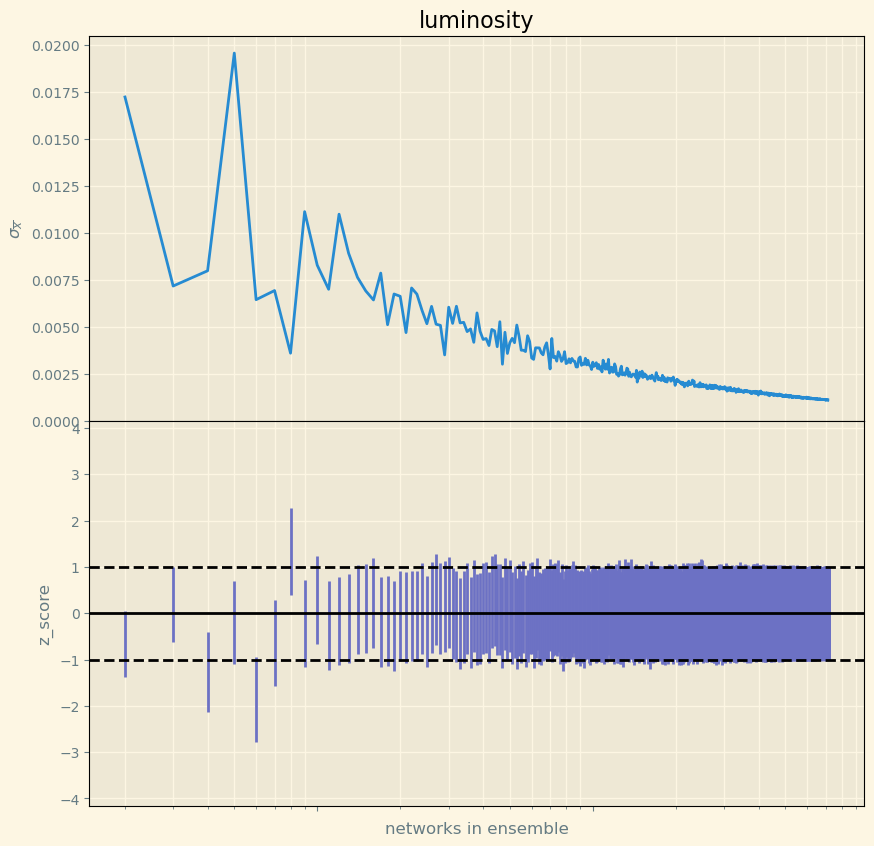

In [37]:
def plot_error_func(output, N):

    colours = [colour["color"] for colour in plt.rcParams["axes.prop_cycle"]]
    
    fig, (ax1, ax2) = plt.subplots(2,1,figsize=(10,10), dpi=100, sharex=True)
    plt.subplots_adjust(hspace=0)
    
    ax1.plot(angry_mob_pred['N'][1:], angry_mob_pred[output+'_std'][1:]/np.sqrt(angry_mob_pred['N'][1:]), label='standard error at N')
    #ax1.axhline(stats.median_abs_deviation(pitchfork_errors_df[output]),linestyle='dashed', color='orange',label='MAD from test set')
    # if output == "effective_T":
    #     ax1.axhline(5,linestyle='dashed', color='green',label='target uncertainty')
    # elif output == "radius":
    #     ax1.axhline(0.01,linestyle='dashed', color='green',label='target uncertainty')
    # elif output == "surface_Z":
    #     ax1.axhline(0.001,linestyle='dashed', color='green',label='target uncertainty')
    # elif output == "luminosity":
    #     ax1.axhline(0.02,linestyle='dashed', color='green',label='target uncertainty')
    # else:
    #     ax1.axhline(0.1,linestyle='dashed', color='green',label='target uncertainty')

    
    #ax1.legend()
    ax1.set_ylabel("$\sigma_\overline{x}$")
    ax1.set_title(output)
    ax1.set_xscale('log')
    ax1.set_ylim(0)
    ax1.set_xticklabels([])
    ax1.grid(which='both', axis='x')

    z_error_on_mean_arr=[]
    ylim_max = 0
    for n in range(1,N-1):
        z_vals = angry_mob_pred[output+'_z'][n]
        z_std = np.std(z_vals)
        z_mean = np.mean(z_vals)
        z_error_on_mean_arr.append(z_std/np.sqrt(len(z_vals)))

        array = [z_mean-z_std,z_mean+z_std]
        check_ylim_max = max(np.abs(array))
        if check_ylim_max > ylim_max:
            ylim_max = check_ylim_max
        
        ax2.plot(np.full(2, n+1), array, color=colours[7])
        
    ax2.axhline(-1, linestyle='dashed', color='black')
    ax2.axhline(0, color='black')
    ax2.axhline(1, linestyle='dashed', color='black')
    ax2.set_ylabel("z_score")
    ax2.set_xscale('log')
    ylim_max = ylim_max*1.5
    ax2.set_ylim(-ylim_max, ylim_max)
    ax2.set_xticklabels([])
    ax2.grid(which='both', axis='x')

    # ax3.plot([n+1 for n in range(N-1)], z_error_on_mean_arr, color='red')
    # ax3.set_ylabel("$\sigma_\overline{z}$")
    ax2.set_xlabel("networks in ensemble")
    # ax3.set_yscale('log')
    # ax3.set_xscale('log')
    # ax3.grid(which='both', axis='x')
    
#plot_error_func('luminosity', 721)
#plot_error_func('radius', 721)
#plot_error_func('surface_Z', 721)
#plot_error_func('effective_T', 721)
#plot_error_func('nu_0_15', 721)
#plot_error_func('nu_0_20', 721)
plot_error_func('luminosity', 721)